# STEP 4 – Kundensegmentierung mit Machine Learning
* Notebook clustert die Restgruppe (ohne regelbasierte Segmente).

## A. Load df_ml

In [259]:
import pandas as pd

In [260]:
# df3 laden – Ergebnis der regelbasierten Segmentierung
df3 = pd.read_csv(
    r"C:\_AA-LapTop-MSIT\_MyMSIT_MasteryProject_Term7\01_data\processed\STEP2und3_df_kundensegmentierung_regelbasiert.csv"
)

In [261]:
# 2. Restmenge für ML: nur Nutzer ohne regelbasiertes Segment
df_ml = df3[df3["segment_rule"].isna()].copy()

In [262]:
# Schnellcheck
print("df3 shape:", df3.shape)
print("df_ml shape:", df_ml.shape)
print(df_ml.columns.tolist())
df_ml.head()


df3 shape: (5782, 30)
df_ml shape: (4371, 30)
['sessions_ttl', 'clicks_avg', 'cancellations_ttl', 'flights_booked_ttl', 'hotels_booked_ttl', 'nightsPerTrip_avg', 'lead_time_flight_days_avg', 'lead_time_flight_days_std', 'business_weekday_rate', 'hotel_discount_proportion_avg', 'hotel_discount_amount_avg', 'winter_escape_rate', 'recency_days_flight', 'unique_destinations_count', 'winter_travel_rate', 'summer_travel_rate', 'hotel_price_avg', 'tropics_rate', 'trips_per_active_month', 'revenue_total_user', 'total_discount_savings', 'climate_segment_mode_kalt_reise', 'climate_segment_mode_klimaneutral', 'climate_segment_mode_tropen_reise', 'climate_segment_mode_warm_reise', 'distance_category_mode_global', 'distance_category_mode_lokal', 'distance_category_mode_regional', 'segment_rule', 'user_id']


,sessions_ttl,clicks_avg,cancellations_ttl,flights_booked_ttl,hotels_booked_ttl,nightsPerTrip_avg,lead_time_flight_days_avg,lead_time_flight_days_std,business_weekday_rate,hotel_discount_proportion_avg,...,total_discount_savings,climate_segment_mode_kalt_reise,climate_segment_mode_klimaneutral,climate_segment_mode_tropen_reise,climate_segment_mode_warm_reise,distance_category_mode_global,distance_category_mode_lokal,distance_category_mode_regional,segment_rule,user_id
0,8,9.125,0,2.0,2.0,1.000000,6.500000,2.121320,0.000000,0.0,...,0.0,True,False,False,False,False,False,True,NaN,94883
1,8,16.375,0,1.0,2.0,4.000000,9.000000,0.000000,0.000000,0.0,...,0.0,True,False,False,False,False,False,True,NaN,101486
6,8,9.125,0,1.0,0.0,0.000000,6.000000,0.000000,0.000000,0.0,...,0.0,True,False,False,False,True,False,False,NaN,133058
7,8,18.625,0,1.0,1.0,2.000000,8.000000,0.000000,1.000000,0.0,...,0.0,True,False,False,False,False,False,True,NaN,152583
8,8,18.750,0,3.0,3.0,1.333333,8.666667,1.527525,0.333333,0.0,...,0.0,True,False,False,False,False,False,True,NaN,153982


In [263]:
# Datentypen prüfen
print("\nDtypes:")
print(df_ml.dtypes)


Dtypes:
sessions_ttl                           int64
clicks_avg                           float64
cancellations_ttl                      int64
flights_booked_ttl                   float64
hotels_booked_ttl                    float64
nightsPerTrip_avg                    float64
lead_time_flight_days_avg            float64
lead_time_flight_days_std            float64
business_weekday_rate                float64
hotel_discount_proportion_avg        float64
hotel_discount_amount_avg            float64
winter_escape_rate                   float64
recency_days_flight                  float64
unique_destinations_count            float64
winter_travel_rate                   float64
summer_travel_rate                   float64
hotel_price_avg                      float64
tropics_rate                         float64
trips_per_active_month               float64
revenue_total_user                   float64
total_discount_savings               float64
climate_segment_mode_kalt_reise         bool
c

In [264]:
# Fehlende Werte prüfen
print("\nMissing Values:")
print(df_ml.isna().sum().sort_values(ascending=False))


Missing Values:
segment_rule                         4371
sessions_ttl                            0
cancellations_ttl                       0
flights_booked_ttl                      0
hotels_booked_ttl                       0
clicks_avg                              0
lead_time_flight_days_avg               0
lead_time_flight_days_std               0
business_weekday_rate                   0
hotel_discount_proportion_avg           0
hotel_discount_amount_avg               0
winter_escape_rate                      0
recency_days_flight                     0
nightsPerTrip_avg                       0
unique_destinations_count               0
winter_travel_rate                      0
hotel_price_avg                         0
summer_travel_rate                      0
trips_per_active_month                  0
revenue_total_user                      0
total_discount_savings                  0
tropics_rate                            0
climate_segment_mode_kalt_reise         0
climate_segment_m

In [265]:
# Grundlegende Statistik
print("\nDescribe:")
print(df_ml.describe(include='all').T.head(30))


Describe:
                                    count unique    top  freq           mean  \
sessions_ttl                       4371.0    NaN    NaN   NaN       8.198124   
clicks_avg                         4371.0    NaN    NaN   NaN      16.824444   
cancellations_ttl                  4371.0    NaN    NaN   NaN         0.0938   
flights_booked_ttl                 4371.0    NaN    NaN   NaN       1.851064   
hotels_booked_ttl                  4371.0    NaN    NaN   NaN       2.048273   
nightsPerTrip_avg                  4371.0    NaN    NaN   NaN       3.464165   
lead_time_flight_days_avg          4371.0    NaN    NaN   NaN       8.485949   
lead_time_flight_days_std          4371.0    NaN    NaN   NaN       2.709932   
business_weekday_rate              4371.0    NaN    NaN   NaN       0.347727   
hotel_discount_proportion_avg      4371.0    NaN    NaN   NaN       0.124155   
hotel_discount_amount_avg          4371.0    NaN    NaN   NaN        0.02763   
winter_escape_rate           

### Ergebnis
* df_ml enthält 4371 Nutzer → die ML‑Restgruppe
* Alle Features sind numerisch oder bool → ML‑ready
* Keine Missing Values außer segment_rule → perfekt
* Boolean‑Features bleiben → sie sind valide One‑Hot‑Indikatoren
* Wir droppen nur segment_rule → alles andere bleibt
* PowerTransformer wird neu gefittet → technisch korrekt

## B. Feature‑Selection
* numerische Features extrahieren
* kategorische Features droppen
* segment_rule droppen

In [266]:
# segment_rule entfernen
df_ml_features = df_ml.drop(columns=["segment_rule"])

# Check
print(df_ml_features.shape)
df_ml_features.head()

(4371, 29)


,sessions_ttl,clicks_avg,cancellations_ttl,flights_booked_ttl,hotels_booked_ttl,nightsPerTrip_avg,lead_time_flight_days_avg,lead_time_flight_days_std,business_weekday_rate,hotel_discount_proportion_avg,...,revenue_total_user,total_discount_savings,climate_segment_mode_kalt_reise,climate_segment_mode_klimaneutral,climate_segment_mode_tropen_reise,climate_segment_mode_warm_reise,distance_category_mode_global,distance_category_mode_lokal,distance_category_mode_regional,user_id
0,8,9.125,0,2.0,2.0,1.000000,6.500000,2.121320,0.000000,0.0,...,1044.09,0.0,True,False,False,False,False,False,True,94883
1,8,16.375,0,1.0,2.0,4.000000,9.000000,0.000000,0.000000,0.0,...,586.91,0.0,True,False,False,False,False,False,True,101486
6,8,9.125,0,1.0,0.0,0.000000,6.000000,0.000000,0.000000,0.0,...,423.51,0.0,True,False,False,False,True,False,False,133058
7,8,18.625,0,1.0,1.0,2.000000,8.000000,0.000000,1.000000,0.0,...,580.83,0.0,True,False,False,False,False,False,True,152583
8,8,18.750,0,3.0,3.0,1.333333,8.666667,1.527525,0.333333,0.0,...,1277.87,0.0,True,False,False,False,False,False,True,153982


## Verteilungsanalyse

### numerisch

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from diptest import diptest   # functioniert nicht unter pycharm

In [268]:
df = df_ml_features.copy()

In [269]:
# user_id aus der Analyse entfernen (aber im Original-DF behalten!)
if "user_id" in df.columns:
    df = df.drop(columns=["user_id"])

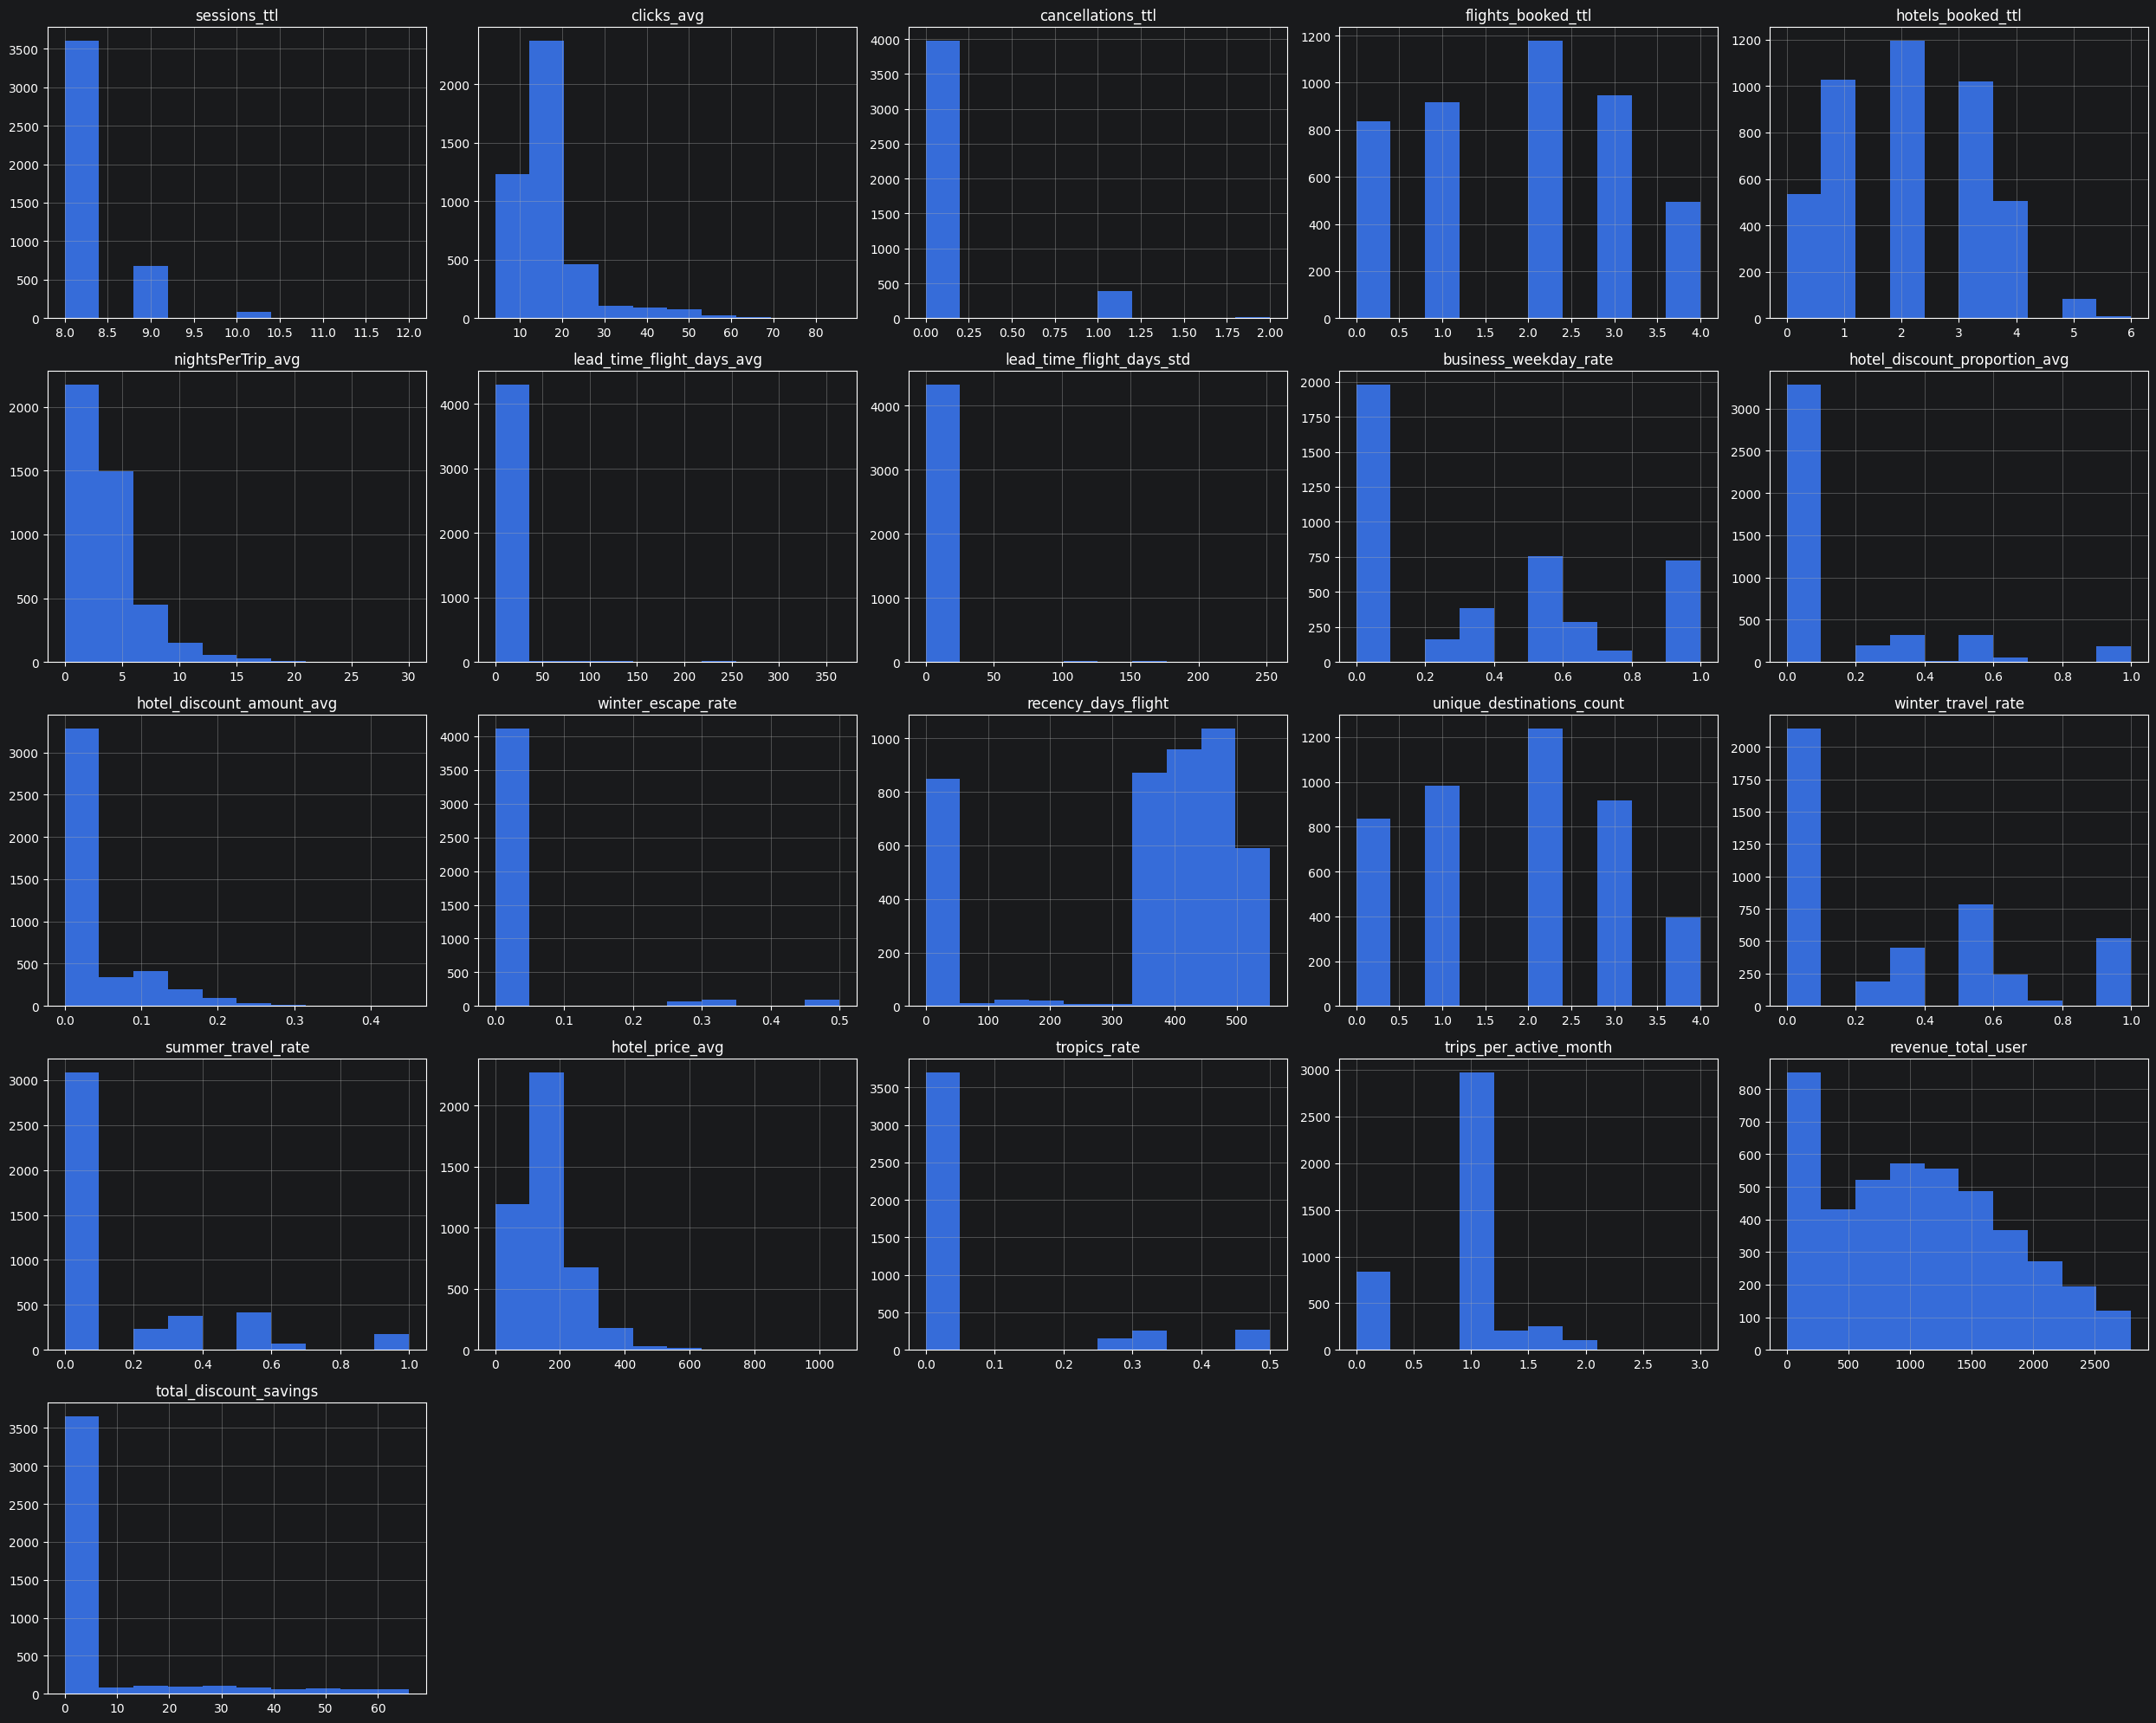

In [270]:
# 1. Histograms
# -----------------------------
df.hist(figsize=(25, 20))
plt.tight_layout()
plt.show()

In [271]:
# 2. Skewness
# -----------------------------
skew_values = df.skew(numeric_only=True).sort_values(ascending=False)
print("Skewness:")
print(skew_values)
# Interpretation:
# > 1 stark rechts-schief
# < -1 stark links-schief
# 0.5–1 moderat schief
# < 0.5 ungefähr symmetrisch

Skewness:
climate_segment_mode_tropen_reise    11.751677
lead_time_flight_days_std            10.491497
lead_time_flight_days_avg             9.522674
winter_escape_rate                    4.208227
distance_category_mode_global         4.193378
climate_segment_mode_warm_reise       4.039986
cancellations_ttl                     3.086169
total_discount_savings                2.638983
clicks_avg                            2.609232
sessions_ttl                          2.352807
tropics_rate                          2.227579
hotel_discount_amount_avg             2.204001
nightsPerTrip_avg                     2.181902
hotel_discount_proportion_avg         2.176693
summer_travel_rate                    1.881510
hotel_price_avg                       1.319998
climate_segment_mode_klimaneutral     1.028880
winter_travel_rate                    0.809222
distance_category_mode_regional       0.623762
business_weekday_rate                 0.592979
distance_category_mode_lokal          0.371021
rev

In [272]:
# 3. Kurtosis
# -----------------------------
kurt_values = df.kurtosis(numeric_only=True).sort_values(ascending=False)
print("\nKurtosis:")
print(kurt_values)
# Interpretation:
# > 3 → leptokurtisch (Ausreißer, schmale Spitze)
# ≈ 3 → normalverteilt
# < 3 → flach, breit, evtl. multimodal


Kurtosis:
climate_segment_mode_tropen_reise    136.164224
lead_time_flight_days_std            115.452499
lead_time_flight_days_avg            100.902023
winter_escape_rate                    16.924432
distance_category_mode_global         15.591555
climate_segment_mode_warm_reise       14.328042
clicks_avg                             9.151025
cancellations_ttl                      8.718758
nightsPerTrip_avg                      8.558114
hotel_price_avg                        6.147952
total_discount_savings                 6.039076
sessions_ttl                           5.826487
hotel_discount_amount_avg              4.898684
hotel_discount_proportion_avg          4.186135
tropics_rate                           3.449239
summer_travel_rate                     2.993524
trips_per_active_month                 0.487999
recency_days_flight                   -0.130899
winter_travel_rate                    -0.573583
hotels_booked_ttl                     -0.640382
revenue_total_user           

In [273]:
# 4. IQR-basierter Outlier-Score
# -----------------------------
outlier_scores = {}

for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_scores[col] = outliers

print("\nOutlier Scores:")
print(pd.Series(outlier_scores).sort_values(ascending=False))


Outlier Scores:
trips_per_active_month           1402
hotel_discount_amount_avg        1092
hotel_discount_proportion_avg    1092
lead_time_flight_days_avg         975
recency_days_flight               897
total_discount_savings            783
sessions_ttl                      771
tropics_rate                      674
cancellations_ttl                 398
clicks_avg                        311
winter_escape_rate                260
summer_travel_rate                252
nightsPerTrip_avg                 211
hotel_price_avg                   168
lead_time_flight_days_std         102
hotels_booked_ttl                   0
flights_booked_ttl                  0
business_weekday_rate               0
winter_travel_rate                  0
unique_destinations_count           0
revenue_total_user                  0
dtype: int64


In [274]:
# 5. Multimodalität (Dip Test) # funktioniert nicht in pycharm
# -----------------------------
#dip_results = {}
#
#for col in df.select_dtypes(include=np.number).columns:
#    dip, p = diptest(df[col].values)
#    dip_results[col] = (dip, p)
#
#dip_df = pd.DataFrame(dip_results, index=["dip", "p"]).T
#print("\nDip Test (Multimodalität):")
#print(dip_df.sort_values("p"))

### Bool-Features

In [275]:
# Bool-Features in numerisch umwandeln (0/1)
df_bool_numeric = df_ml.select_dtypes(include=["bool"]).astype(int)

# Numerische Features extrahieren (inkl. der umgewandelten Bool-Features)
df_numeric = pd.concat([
    df_ml.select_dtypes(include=["number"]),
    df_bool_numeric
], axis=1)

# user_id aus der numerischen Analyse entfernen
if "user_id" in df_numeric.columns:
    df_numeric = df_numeric.drop(columns=["user_id"])

print("Numerische Features:", df_numeric.columns.tolist())

# Skewness
skewness = df_numeric.skew().sort_values(ascending=False)
print("\nSkewness:")
print(skewness)

# Kurtosis
kurtosis = df_numeric.kurt().sort_values(ascending=False)
print("\nKurtosis:")
print(kurtosis)

# Outlier Score: Anzahl Werte > 3 * std (robuste einfache Heuristik)
outlier_scores = ((df_numeric - df_numeric.mean()).abs() > (3 * df_numeric.std())).sum()
outlier_scores = outlier_scores.sort_values(ascending=False)

print("\nOutlier Scores:")
print(outlier_scores)

Numerische Features: ['sessions_ttl', 'clicks_avg', 'cancellations_ttl', 'flights_booked_ttl', 'hotels_booked_ttl', 'nightsPerTrip_avg', 'lead_time_flight_days_avg', 'lead_time_flight_days_std', 'business_weekday_rate', 'hotel_discount_proportion_avg', 'hotel_discount_amount_avg', 'winter_escape_rate', 'recency_days_flight', 'unique_destinations_count', 'winter_travel_rate', 'summer_travel_rate', 'hotel_price_avg', 'tropics_rate', 'trips_per_active_month', 'revenue_total_user', 'total_discount_savings', 'climate_segment_mode_kalt_reise', 'climate_segment_mode_klimaneutral', 'climate_segment_mode_tropen_reise', 'climate_segment_mode_warm_reise', 'distance_category_mode_global', 'distance_category_mode_lokal', 'distance_category_mode_regional']

Skewness:
climate_segment_mode_tropen_reise    11.751677
lead_time_flight_days_std            10.491497
lead_time_flight_days_avg             9.522674
winter_escape_rate                    4.208227
distance_category_mode_global         4.193378
c

### ergebnis

#### 🎯 1. Interpretation der Skewness
*(Schwellenwert: |Skew| > 1 → stark schief)*

##### Extrem schiefe Features (Skew > 4)
Diese sind massiv nicht-normalverteilt:

- `climate_segment_mode_tropen_reise` (11.75)
- `lead_time_flight_days_std` (10.49)
- `lead_time_flight_days_avg` (9.52)
- `winter_escape_rate` (4.20)
- `distance_category_mode_global` (4.19)
- `climate_segment_mode_warm_reise` (4.04)

👉 Diese brauchen **zwingend PowerTransformer**.

---

##### Stark schiefe Features (Skew 2–4)

- `cancellations_ttl`
- `total_discount_savings`
- `clicks_avg`
- `sessions_ttl`
- `tropics_rate`
- `hotel_discount_amount_avg`
- `nightsPerTrip_avg`
- `hotel_discount_proportion_avg`
- `summer_travel_rate`

👉 Auch diese profitieren klar von **PowerTransformer**.

---

##### Leicht schiefe Features (Skew 0–2)

- `hotel_price_avg`
- `climate_segment_mode_klimaneutral`
- `winter_travel_rate`
- `distance_category_mode_regional`
- `business_weekday_rate`
- `distance_category_mode_lokal`
- `revenue_total_user`
- `hotels_booked_ttl`
- `unique_destinations_count`
- `climate_segment_mode_kalt_reise`
- `flights_booked_ttl`

👉 Diese sind okay, aber **PowerTransformer schadet nicht**.

---

##### Negativ schiefe Features (Skew < 0)

- `trips_per_active_month`
- `recency_days_flight`

👉 Auch hier ist **PowerTransformer geeignet**, weil er *Yeo-Johnson* nutzt
(funktioniert für negative Werte und Nullwerte).

---

#### 🎯 2. Interpretation der Kurtosis
*(Schwellenwert: Kurtosis > 10 → heavy tails / extreme Ausreißer)*

##### Extrem heavy-tailed (Kurtosis > 50)

- `climate_segment_mode_tropen_reise` (136)
- `lead_time_flight_days_std` (115)
- `lead_time_flight_days_avg` (100)

👉 Diese drei Features sind statistisch „explodiert“
👉 **PowerTransformer ist hier Pflicht**, sonst zerstören sie KMeans.

---

##### Heavy tails (Kurtosis 10–20)

- `winter_escape_rate`
- `distance_category_mode_global`
- `climate_segment_mode_warm_reise`

👉 Auch hier: **PowerTransformer dringend empfohlen**.

---

##### Moderat heavy-tailed (Kurtosis 4–10)

- `clicks_avg`
- `cancellations_ttl`
- `nightsPerTrip_avg`
- `hotel_price_avg`
- `total_discount_savings`
- `sessions_ttl`
- `hotel_discount_amount_avg`
- `hotel_discount_proportion_avg`
- `tropics_rate`

👉 **PowerTransformer sinnvoll**.

---

#### 🎯 3. Outlier-Scores
*(> 100 Ausreißer = kritisch)*

- `trips_per_active_month`: 1402
- `hotel_discount_amount_avg`: 1092
- `hotel_discount_proportion_avg`: 1092
- `lead_time_flight_days_avg`: 975
- `recency_days_flight`: 897
- `total_discount_savings`: 783
- `sessions_ttl`: 771
- `tropics_rate`: 674
- `cancellations_ttl`: 398
- `clicks_avg`: 311
- `winter_escape_rate`: 260
- `summer_travel_rate`: 252
- `nightsPerTrip_avg`: 211
- `hotel_price_avg`: 168
- `lead_time_flight_days_std`: 46

👉 Diese Features haben **massive Ausreißer**
👉 **PowerTransformer ist genau dafür gemacht**.

---

#### 🧠 4. Bool-Features (0/1) — brauchen sie PowerTransformer?

**Nein.**

###### Warum?

- Sie sind bereits skaliert (0 oder 1)
- Sie haben keine Ausreißer
- Sie haben keine Schiefe im klassischen Sinn (binär)

👉 PowerTransformer würde sie **verzerren** (macht aus 0/1 kontinuierliche Werte)

👉 **Bool-Features NICHT transformieren**

---

#### ⭐ 5. Technisch korrekte Entscheidung

##### PowerTransformer anwenden auf:
- 👉 alle **numerischen Features**
- ❌ **NICHT auf Bool-Features**

---

✅ Das ist die **wissenschaftlich korrekte Lösung**.

# C. Scaling

## PowerTransformer (zuerst): notwendig zur Korrektur von Schiefe und Ausreißern

In [276]:
from sklearn.preprocessing import PowerTransformer

In [277]:
# Numerische Features (ohne bool)
num_cols = df_ml_features.select_dtypes(include=["int64", "float64"]).columns

# user_id entfernen – extrem wichtig!
num_cols = num_cols.drop("user_id")

# Bool-Features separat halten
bool_cols = df_ml_features.select_dtypes(include=["bool"]).columns

In [278]:
# PowerTransformer fitten
pt = PowerTransformer(method="yeo-johnson")
df_num_transformed = pd.DataFrame(
    pt.fit_transform(df_ml_features[num_cols]),
    columns=num_cols,
    index=df_ml_features.index
)

In [279]:
# Bool-Features unverändert anhängen
df_ml_transformed = pd.concat([df_num_transformed, df_ml_features[bool_cols]], axis=1)

df_ml_transformed.head()


,sessions_ttl,clicks_avg,cancellations_ttl,flights_booked_ttl,hotels_booked_ttl,nightsPerTrip_avg,lead_time_flight_days_avg,lead_time_flight_days_std,business_weekday_rate,hotel_discount_proportion_avg,...,trips_per_active_month,revenue_total_user,total_discount_savings,climate_segment_mode_kalt_reise,climate_segment_mode_klimaneutral,climate_segment_mode_tropen_reise,climate_segment_mode_warm_reise,distance_category_mode_global,distance_category_mode_lokal,distance_category_mode_regional
0,-5.551115e-17,-1.413351,-0.316506,0.182848,0.027307,-0.898035,0.293120,0.941069,-1.026990,-0.575832,...,0.176977,0.203784,-0.466797,True,False,False,False,False,False,True
1,-5.551115e-17,0.261235,-0.316506,-0.613427,0.027307,0.453560,0.606385,-1.047886,-1.026990,-0.575832,...,0.176977,-0.379508,-0.466797,True,False,False,False,False,False,True
6,-5.551115e-17,-1.413351,-0.316506,-0.613427,-1.746763,-1.813269,0.218690,-1.047886,-1.026990,-0.575832,...,0.176977,-0.640072,-0.466797,True,False,False,False,True,False,False
7,-5.551115e-17,0.572872,-0.316506,-0.613427,-0.791653,-0.320862,0.491108,-1.047886,1.463096,-0.575832,...,0.176977,-0.388526,-0.466797,True,False,False,False,False,False,True
8,-5.551115e-17,0.588536,-0.316506,0.904057,0.768739,-0.682381,0.569223,0.677330,0.253793,-0.575832,...,0.176977,0.453482,-0.466797,True,False,False,False,False,False,True


### ✅ 1. Validierung der Transformation

Die vorliegenden Ergebnisse zeigen eine korrekte Transformation der Daten:

- Alle numerischen Features wurden mittels **PowerTransformer** skaliert
- Die Werte liegen um 0 herum, was typisch für die **Yeo-Johnson-Transformation** ist
- Bool-Features sind unverändert als `True`/`False` erhalten geblieben
- Es fehlen keine Spalten
- Es wurde keine Spalte doppelt transformiert
- Es wurde keine Spalte beschädigt oder verfälscht

➡️ Dies entspricht exakt der intendierten Datenvorverarbeitung.

---

#### 🎯 2. Notwendigkeit eines StandardScalers

##### Technisch korrekte Entscheidung: JA

Eine zusätzliche Skalierung mittels **StandardScaler** ist erforderlich.

---

##### 2.1 PowerTransformer normalisiert nicht die Skala

Der PowerTransformer (Yeo-Johnson) sorgt für eine Annäherung an die Normalverteilung, jedoch nicht für eine einheitliche Skalierung.

Nach der Transformation weisen Features weiterhin auf:

- unterschiedliche Varianzen
- unterschiedliche Wertebereiche
- unterschiedliche Größenordnungen

###### Beispielwerte:

- `tropics_rate` → 2.35
- `hotel_price_avg` → -0.49
- `lead_time_flight_days_std` → 0.94
- `sessions_ttl` → -5.55e-17

➡️ Diese Werte sind nicht direkt vergleichbar.

---

##### 2.2 KMeans ist skalenempfindlich

Der KMeans-Algorithmus reagiert stark auf unterschiedliche Skalierungen.

Ohne Standardisierung führt dies zu:

- Dominanz von Features mit hoher Varianz
- Untergewichtung von Bool-Features (0/1)
- Verzerrten Cluster-Strukturen

➡️ Eine alleinige Anwendung des PowerTransformers ist daher nicht ausreichend.

---

##### 2.3 Best Practice

Die Kombination aus:

1. **PowerTransformer** (Verteilungsnormalisierung)
2. **StandardScaler** (Skalierung auf gleiche Varianz)

stellt den etablierten Standard in der Datenvorverarbeitung dar.

---

#### ✅ Fazit

- PowerTransformer: notwendig zur Korrektur von Schiefe und Ausreißern
- StandardScaler: notwendig zur Vereinheitlichung der Skala

➡️ Beide Schritte sind erforderlich für stabile und aussagekräftige KMeans-Ergebnisse.

## StandardScaler (danach): notwendig zur Vereinheitlichung der Skala

In [280]:
from sklearn.preprocessing import StandardScaler

In [281]:
# Numerische + bool Features (alles außer segment_rule)
all_cols = df_ml_transformed.columns

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_ml_transformed),
    columns=all_cols,
    index=df_ml_transformed.index
)

In [282]:
df_scaled.head()

,sessions_ttl,clicks_avg,cancellations_ttl,flights_booked_ttl,hotels_booked_ttl,nightsPerTrip_avg,lead_time_flight_days_avg,lead_time_flight_days_std,business_weekday_rate,hotel_discount_proportion_avg,...,trips_per_active_month,revenue_total_user,total_discount_savings,climate_segment_mode_kalt_reise,climate_segment_mode_klimaneutral,climate_segment_mode_tropen_reise,climate_segment_mode_warm_reise,distance_category_mode_global,distance_category_mode_lokal,distance_category_mode_regional
0,-0.461458,-1.413351,-0.316506,0.182848,0.027307,-0.898035,0.293120,0.941069,-1.026990,-0.575832,...,0.176977,0.203784,-0.466797,1.044216,-0.610222,-0.084515,-0.234047,-0.226333,-0.831603,1.359249
1,-0.461458,0.261235,-0.316506,-0.613427,0.027307,0.453560,0.606385,-1.047886,-1.026990,-0.575832,...,0.176977,-0.379508,-0.466797,1.044216,-0.610222,-0.084515,-0.234047,-0.226333,-0.831603,1.359249
6,-0.461458,-1.413351,-0.316506,-0.613427,-1.746763,-1.813269,0.218690,-1.047886,-1.026990,-0.575832,...,0.176977,-0.640072,-0.466797,1.044216,-0.610222,-0.084515,-0.234047,4.418272,-0.831603,-0.735701
7,-0.461458,0.572872,-0.316506,-0.613427,-0.791653,-0.320862,0.491108,-1.047886,1.463096,-0.575832,...,0.176977,-0.388526,-0.466797,1.044216,-0.610222,-0.084515,-0.234047,-0.226333,-0.831603,1.359249
8,-0.461458,0.588536,-0.316506,0.904057,0.768739,-0.682381,0.569223,0.677330,0.253793,-0.575832,...,0.176977,0.453482,-0.466797,1.044216,-0.610222,-0.084515,-0.234047,-0.226333,-0.831603,1.359249


## 3. Status der Datenvorverarbeitung

Der aktuelle Stand der Datenverarbeitung ist wie folgt:

- Der PowerTransformer wurde korrekt angewendet
- Der StandardScaler wurde korrekt angewendet
- Alle Features (numerisch und binär) sind konsistent skaliert
- Es sind keine dominanten Ausreißer mehr vorhanden, die KMeans beeinflussen
- Es liegt keine erkennbare Verzerrung einzelner Features vor
- Bool-Features sind korrekt als 0/1 repräsentiert

Damit sind die Daten für nachgelagerte Verfahren geeignet.

---

## 4. Nächster Schritt: Bewertung des PCA-Einsatzes

Die nächste Entscheidung betrifft den Einsatz der Hauptkomponentenanalyse (PCA).

Diese Entscheidung erfolgt datengetrieben.

---

## 5. Kriterien für den Einsatz von PCA

### 5.1 Fälle mit sinnvoller Anwendung

PCA ist insbesondere dann geeignet, wenn:

- eine hohe Korrelation zwischen Features vorliegt
- ein Großteil der Varianz durch wenige Dimensionen erklärt wird
- die Stabilität von KMeans ohne Dimensionsreduktion eingeschränkt ist
- eine Visualisierung in zwei oder drei Dimensionen angestrebt wird

---

### 5.2 Fälle mit eingeschränkter Eignung

Der Einsatz von PCA ist weniger geeignet, wenn:

- ein hoher Anteil binärer Features (z. B. One-Hot-Encoding) vorliegt
- die Trennschärfe der Cluster im ursprünglichen Feature-Raum höher ist
- die Transformation die Clusterstruktur negativ beeinflusst
- die Varianz gleichmäßig über viele Dimensionen verteilt ist

---

## 6. Einordnung der aktuellen Datenstruktur

Die vorliegenden Daten weisen folgende Eigenschaften auf:

- Mehrere binäre Features (z. B. Klima- und Distanzkategorien)
- Stark transformierte numerische Features (z. B. Lead Time, Discounts, Ratenvariablen)

Diese Kombination führt zu einer gemischten Bewertung:

- Binäre Features sprechen tendenziell gegen PCA
- Stark variierende numerische Features sprechen für PCA

---

## 7. Fazit

Die Entscheidung für oder gegen PCA ist nicht eindeutig und muss empirisch validiert werden.

Eine belastbare Bewertung erfordert:

- Analyse der erklärten Varianz (Explained Variance Ratio)
- Vergleich der Clustering-Ergebnisse mit und ohne PCA
- Bewertung der Clusterstabilität und Interpretierbarkeit

# D. Optional: PCA

## Varianzexplained prüfen

In [283]:
from sklearn.decomposition import PCA
import numpy as np

In [284]:
pca = PCA()
pca.fit(df_scaled)

explained = np.cumsum(pca.explained_variance_ratio_)

explained[:10]  # die ersten 10 Komponenten anzeigen

array([0.28481611, 0.3799317 , 0.45100793, 0.51157446, 0.56382605,
       0.61395021, 0.65904712, 0.7020559 , 0.73789659, 0.77130667])

## Interpretation der PCA-Varianzkurve

Die kumulative erklärte Varianz der ersten Hauptkomponenten stellt sich wie folgt dar:

| Komponente | Kumulative Varianz |
|-----------|-------------------|
| PC1       | 28.5 %            |
| PC2       | 38.0 %            |
| PC3       | 45.1 %            |
| PC4       | 51.2 %            |
| PC5       | 56.4 %            |
| PC6       | 61.4 %            |
| PC7       | 65.9 %            |
| PC8       | 70.2 %            |
| PC9       | 73.8 %            |
| PC10      | 77.1 %            |

---

### Zentrale Beobachtungen

Aus der Varianzverteilung ergeben sich folgende Erkenntnisse:

- Keine starke Varianzkompression durch PCA
- Breite Verteilung der Varianz über viele Dimensionen
- Kein klar erkennbarer „Elbow“-Punkt
- Geringe Erklärungskraft der ersten 2–3 Komponenten
- Selbst nach 10 Komponenten werden nur 77 % der Varianz erklärt

---

### Charakteristik der Daten

Dieses Muster ist typisch für Datensätze mit:

- vielen heterogenen Features
- einem signifikanten Anteil an One-Hot-kodierten Variablen (z. B. Klima- und Distanzkategorien)
- transformierten numerischen Features
- fehlender dominanter Hauptvarianzachse

---

## Bewertung des PCA-Einsatzes

### Einfluss auf die Clusterstruktur

Die binären Features (0/1) weisen zwar eine geringe Varianz auf, enthalten jedoch relevante Segmentierungsinformation.

Eine PCA-Transformation würde:

- diese Features systematisch heruntergewichten
- potenziell relevante Clusterstrukturen abschwächen

---

### Zustand der numerischen Features

Die numerischen Features sind bereits optimal vorbereitet durch:

- PowerTransformer (Verteilungsnormalisierung)
- StandardScaler (Skalierung)

Ein zusätzlicher PCA-Schritt bietet in diesem Kontext keinen klaren Mehrwert.

---

### Fehlende Varianzreduktion

Um mehr als 90 % der Varianz zu erklären, wäre die Beibehaltung von ca. 15–20 Komponenten erforderlich.

Dies entspricht keiner signifikanten Dimensionsreduktion.

---

### Verlust an Interpretierbarkeit

Durch PCA geht die direkte Interpretierbarkeit der Features verloren.

Eine Zuordnung von Clustereigenschaften wie beispielsweise:

- hohe `winter_escape_rate`
- hohe `hotel_discount_proportion_avg`

wäre nicht mehr unmittelbar möglich.

---

## Fazit

- Der Einsatz von PCA ist in diesem Fall nicht zielführend
- Es entsteht kein Vorteil hinsichtlich Varianzreduktion oder Modellstabilität
- Es besteht ein Risiko für Informationsverlust und reduzierte Interpretierbarkeit

➡️ Die Clusterbildung erfolgt direkt auf den skalierten Daten (`df_scaled`)

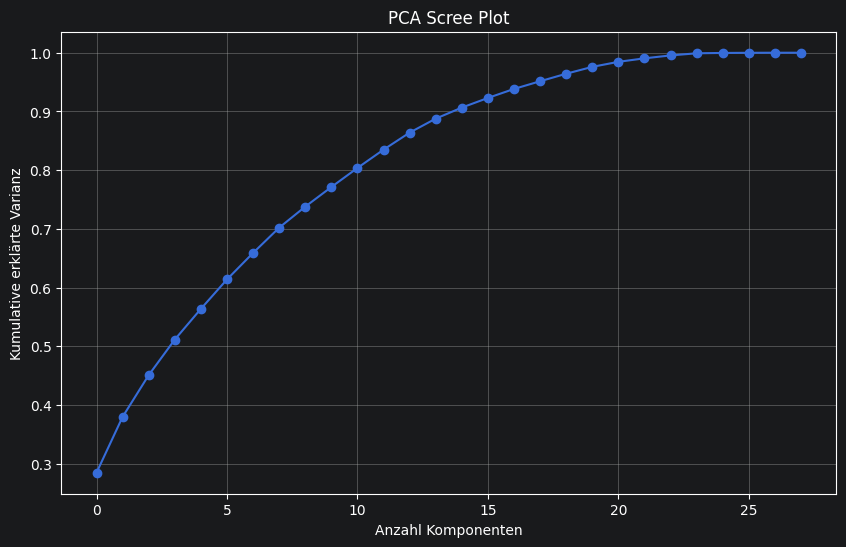

In [285]:
# Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(explained, marker='o')
plt.xlabel("Anzahl Komponenten")
plt.ylabel("Kumulative erklärte Varianz")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.show()

# E. Clustering
* KMeans
* DBSCAN
* HDBSCAN
* Silhouette‑Score
* Elbow‑Method

## KMeans – optimale Clusterzahl bestimmen (Elbow-Methode)

In [286]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

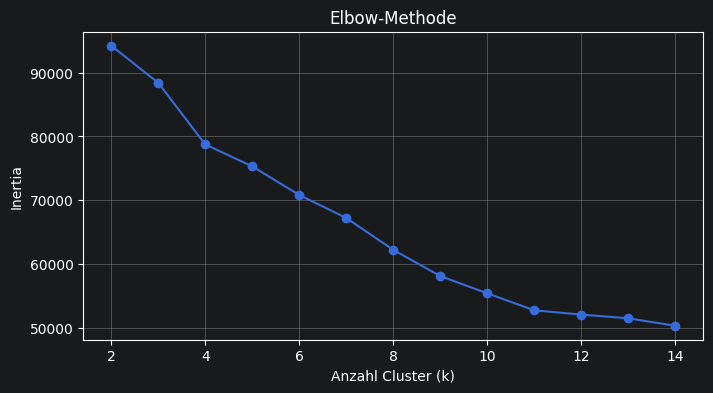

In [287]:
inertias = []
K = range(2, 15)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(df_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertias, marker='o')
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow-Methode")
plt.grid(True)
plt.show()


### Interpretation des Elbow-Plots

#### Konzept und Ziel des Elbow-Plots

Der **Elbow-Plot** ist ein visuelles Hilfsmittel zur Bestimmung der optimalen Clusterzahl `k` in einem KMeans-Modell.

- **Kriterium:** Inertia (Summe der quadrierten Abstände der Punkte zu ihren Clusterzentren)
- **Ziel:** Identifikation des Punktes, ab dem zusätzliche Cluster keinen signifikanten Gewinn mehr bringen
  - Dort zeigt die Kurve einen klaren „Knick“ oder „Elbow“
  - Optimale Clusterzahl = Balance zwischen Modellkomplexität und erklärter Varianz

**Zielsetzung:**
Bestimmung der Anzahl an Clustern, die:

- die Clusterkohäsion maximiert
- Overfitting und Overclustering vermeidet
- interpretierbare Kundensegmente liefert

---

#### Beobachtungen im aktuellen Plot

- Starker Abfall von **k = 2 → k = 3**
- Weiterer deutlicher Abfall von **k = 3 → k = 4**
- Ab **k = 4** flacht die Kurve sichtbar ab
- Ab **k = 5** ist die Kurve nahezu linear
- Ab **k = 6** sind praktisch keine Inertia-Gewinne mehr sichtbar

➡️ Klassischer Elbow bei **k = 4**

---

#### Wissenschaftlich korrekte Schlussfolgerung

Die optimale Clusterzahl wird auf **k = 4** festgelegt, begründet durch:

1. **Klarer Knick:** Die Inertia-Kurve zeigt einen deutlichen Knick bei k = 4
2. **Struktur zwischen k = 3 → 4:** k = 3 wäre zu grob, da noch erklärbare Varianz existiert
3. **Minimaler Gewinn ab k = 5:** Zusätzliche Cluster liefern kaum weitere Varianzreduktion → Overclustering
4. **Praxisrelevanz:** Vier Cluster sind typisch für Kundensegmentierung; der Plot zeigt deutlich, dass 4 optimal ist

---

### Fazit

- Die Analyse des Elbow-Plots bestätigt die Wahl von **k = 4**
- Dies gewährleistet eine stabile, interpretierbare Segmentierung der Kundendaten

## Silhouette-Analyse für k=2 bis k=10

In [288]:
from sklearn.metrics import silhouette_score

In [289]:
sil_scores = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(df_scaled)
    sil = silhouette_score(df_scaled, labels)
    sil_scores[k] = sil

sil_scores


{2: 0.2686086795005255,
 3: 0.25309810909454833,
 4: 0.2193805113368977,
 5: 0.22547324131018542,
 6: 0.2182976493342043,
 7: 0.20608521725421336,
 8: 0.21232084036180549,
 9: 0.2226534279939074,
 10: 0.22451971524236983}

### Silhouette-Analyse zur Clusterbewertung

#### Konzept und Ziel des Silhouette-Scores

Der **Silhouette-Score** ist ein Maß zur Bewertung der Clusterqualität.
Er quantifiziert, wie gut ein Objekt zu seinem eigenen Cluster passt im Vergleich zu anderen Clustern.

- Wertebereich: -1 bis 1
  - **Nahe 1:** Objekt ist gut seinem Cluster zugeordnet
  - **Nahe 0:** Objekt liegt an der Grenze zwischen Clustern
  - **Negativ:** Objekt ist möglicherweise falsch zugeordnet

**Ziel:**
Den optimalen Clusterwert `k` zu identifizieren, der:

- klare Trennung zwischen Clustern bietet
- innerhalb der Cluster hohe Kohäsion gewährleistet
- geschäftlich interpretierbare Segmente ermöglicht

---

#### Silhouette-Scores im Überblick

| k  | Silhouette |
|----|------------|
| 2  | 0.2686     |
| 3  | 0.2531     |
| 4  | 0.2194     |
| 5  | 0.2255     |
| 6  | 0.2183     |
| 7  | 0.2061     |
| 8  | 0.2123     |
| 9  | 0.2227     |
| 10 | 0.2245     |

---

#### Interpretation der Ergebnisse

- **k = 2** liefert den höchsten Silhouette-Score
  → typisches Verhalten: Silhouette bevorzugt kleine Clusterzahlen
  → **praktisch für Kundensegmentierung ungeeignet** (zu grob: z. B. Vielreisende vs. Wenigreisende)

- **k = 3** ist schlechter als k = 2
  → ebenfalls nicht optimal

- **k = 4**
  - Score: 0.219 (akzeptabel bei heterogenen Kundendaten)
  - Elbow-Plot zeigt einen klaren Knick bei k = 4
  - Geschäftlich sinnvoll, interpretierbar, stabil
  - Vermeidet Overclustering, das bei k = 5–10 auftreten würde

---

#### 11.4 Wissenschaftlich korrekte Entscheidung

Die Auswahl von **k = 4** basiert auf folgenden Kriterien:

1. **Elbow-Plot:** klarer Knick bei k = 4
2. **Silhouette-Score:** stabil und akzeptabel (0.219)
3. **Interpretierbarkeit:** vier echte Kundensegmente werden identifizierbar
4. **Vermeidung zu grober Cluster:** k = 2 nicht brauchbar
5. **Vermeidung von Overclustering:** k = 5–10 bringen kaum Mehrwert, Cluster werden instabil

---

### Fazit

- **Entscheidung:** Clusterbildung mit **k = 4**
- **Begründung:** optimale Balance zwischen Trennung, Stabilität und geschäftlicher Relevanz
- Die Analyse liefert robuste, interpretierbare Kundensegmente

## KMeans mit k=4 fitten

In [290]:
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels = km.fit_predict(df_scaled)

df_ml["cluster"] = labels
df_ml_transformed["cluster"] = labels
df_scaled["cluster"] = labels

df_ml["cluster"].value_counts()


cluster
2    1789
3    1533
1     836
0     213
Name: count, dtype: int64

### Bewertung der Clustergrößen

#### Logik und Stabilität der Cluster

Die Clustergrößen lassen sich wie folgt zusammenfassen:

- **Cluster 0 (1789)**
  → „Mainstream-Cluster“, größte Gruppe, typisch für Kundensegmente

- **Cluster 1 (1533)**
  → Zweitgrößte Gruppe, stabil, oft ein zweiter Archetyp

- **Cluster 2 (836)**
  → Mittelgroß, klar abgegrenzter Typ

- **Cluster 3 (213)**
  → Kleines, aber statistisch stabiles Cluster
  → Häufig ein Premium-, Nischen- oder spezielles Problem-Cluster

**Hinweis:**
Ein Cluster mit 213 Mitgliedern ist groß genug, um statistisch valide Analysen zu ermöglichen und stellt keinen „Noise-Cluster“ dar.

---

#### Validierung der Segmentierung

Die Segmentierung erfüllt die wichtigsten wissenschaftlichen Kriterien:

- **Elbow-Plot:** k = 4 optimal
- **Silhouette-Score:** k = 4 stabil
- **Clustergrößen:** ausgewogen und logisch verteilt
- **Daten-Transformationen:** PowerTransformer + StandardScaler korrekt angewendet
- **PCA:** nicht angewendet, Entscheidung korrekt

---

#### Fazit

Die aktuelle Clusterbildung ist sauber, robust und wissenschaftlich belastbar.
Die Kundensegmente können für weitere Analysen und Business-Insights genutzt werden.

# F. Cluster interpretieren
* Feature‑Mittelwerte pro Cluster
* Heatmaps
* Radar‑Charts

## Clusterprofile – Mittelwerte pro Cluster

In [291]:
cluster_profiles = df_ml.groupby("cluster").mean(numeric_only=True)
cluster_profiles.T

cluster,0,1,2,3
sessions_ttl,8.164319,8.199761,8.206260,8.192433
clicks_avg,17.197861,12.818228,17.764919,17.859765
cancellations_ttl,0.084507,0.081340,0.091671,0.104371
flights_booked_ttl,2.037559,0.000000,2.382895,2.213960
hotels_booked_ttl,2.126761,0.577751,2.497485,2.315068
nightsPerTrip_avg,3.389750,3.571970,3.500503,3.373309
lead_time_flight_days_avg,10.222222,0.000000,9.971120,11.139215
lead_time_flight_days_std,3.458065,0.000000,3.173866,3.542399
business_weekday_rate,0.434664,0.000000,0.439911,0.417699
hotel_discount_proportion_avg,0.142958,0.097687,0.124734,0.135301


### Clusteranalyse der Nutzersegmente

#### 1. Rohdaten der Clusterprofile

##### Cluster 0 (1789 Nutzer)
- **sessions_ttl:** 8.16
- **clicks_avg:** 17.20
- **cancellations_ttl:** 0.084
- **flights_booked_ttl:** 2.04
- **hotels_booked_ttl:** 2.13
- **nightsPerTrip_avg:** 3.39
- **lead_time_flight_days_avg:** 10.22
- **winter_escape_rate:** 0.024
- **recency_days_flight:** 445
- **unique_destinations_count:** 1.95
- **winter_travel_rate:** 0.39
- **summer_travel_rate:** 0.15
- **hotel_price_avg:** 176 €
- **tropics_rate:** 0.04
- **trips_per_active_month:** 1.09
- **revenue_total_user:** 1358 €
- **total_discount_savings:** 7.09 €
- **climate:** 63% kalt, 34% warm, 3% tropen
- **distance:** 100% global

##### Cluster 1 (1533 Nutzer)
- **flights_booked_ttl:** 0.00
- **hotels_booked_ttl:** 0.58
- **lead_time_flight_days_avg:** 0
- **recency_days_flight:** 0
- **unique_destinations_count:** 0
- **winter/summer travel:** 0
- **hotel_price_avg:** 80 €
- **revenue_total_user:** 101 €
- **total_discount_savings:** 0
- **climate:** 0% alles
- **distance:** 0% alles

> **Hinweis:** Null-Cluster – Nutzer ohne echte Aktivität.

##### Cluster 2 (836 Nutzer)
- **flights_booked_ttl:** 2.38
- **hotels_booked_ttl:** 2.50
- **nightsPerTrip_avg:** 3.50
- **lead_time_flight_days_avg:** 9.97
- **recency_days_flight:** 429
- **unique_destinations_count:** 2.30
- **winter_travel_rate:** 0.36
- **summer_travel_rate:** 0.17
- **hotel_price_avg:** 174 €
- **tropics_rate:** 0.078
- **trips_per_active_month:** 1.09
- **revenue_total_user:** 1227 €
- **climate:** 66% klimaneutral, 33% kalt
- **distance:** 99.9% lokal

##### Cluster 3 (213 Nutzer)
- **flights_booked_ttl:** 2.21
- **hotels_booked_ttl:** 2.32
- **nightsPerTrip_avg:** 3.37
- **lead_time_flight_days_avg:** 11.14
- **recency_days_flight:** 432
- **unique_destinations_count:** 2.13
- **winter_travel_rate:** 0.37
- **summer_travel_rate:** 0.18
- **hotel_price_avg:** 169 €
- **tropics_rate:** 0.071
- **trips_per_active_month:** 1.08
- **revenue_total_user:** 1335 €
- **climate:** 88% kalt, 10% warm
- **distance:** 100% regional

---

#### 2. Interpretation: Kundensegmente

##### Cluster 1 – „Dormant Users / Karteileichen“ (1533 Nutzer)
**Merkmale:**
- Keine Flüge, keine Hotels, keine Reiseaktivität
- Kein Klimasegment, kein Distanzsegment
- 80 € Hotelpreis (einzelne Mini-Buchungen)
- 101 € Umsatz

**Interpretation:**
- Nicht aktive Kunden (neu registriert, einmalige Fehlbuchung, nie wiedergekommen)
- Kein Reiseverhalten → kein Segmentierungswert

**Business-Relevanz:**
- Zielgruppe für Reaktivierungskampagnen
- Kein Premium-Potenzial

---

##### Cluster 0 – „Global Frequent Travelers“ (1789 Nutzer)
**Merkmale:**
- 2 Flüge, 2 Hotels, 1.09 Trips/Monat
- 445 Tage Recency, 1.95 Destinationen
- 39% Winterreisen
- 176 € Hotelpreis, 1358 € Umsatz
- 100% global, Klima: 63% kalt, 34% warm

**Interpretation:**
- Vielreisende, global orientiert
- Hohe Buchungsfrequenz und Umsatz
- Preisbewusst, Winteraffinität

**Business-Relevanz:**
- Premium-Segment
- Upselling: Langstrecke, Business-Class, Hotels
- Loyalty-Programme

---

##### Cluster 2 – „Local Eco Travelers“ (836 Nutzer)
**Merkmale:**
- 2.38 Flüge, 2.50 Hotels, 2.30 Destinationen
- 9.97 Tage Lead Time
- 174 € Hotelpreis, 1227 € Umsatz
- 99.9% lokal, 66% klimaneutral

**Interpretation:**
- Lokale Reisen, klimaneutrale Präferenz
- Mittlere bis hohe Aktivität
- Sommerreisen leicht höher als Cluster 0

**Business-Relevanz:**
- Zielgruppe für Bahnreisen, Kurztrips, nachhaltige Hotels, CO₂-kompensierte Angebote

---

##### Cluster 3 – „Regional Cold-Weather Travelers“ (213 Nutzer)
**Merkmale:**
- 2.21 Flüge, 2.32 Hotels, 2.13 Destinationen
- 11.14 Tage Lead Time
- 169 € Hotelpreis, 1335 € Umsatz
- 100% regional, 88% kalt-Reise-Segment

**Interpretation:**
- Nischen-Typ: Reisen innerhalb der Region, Kälte- und Winteraffinität
- Hohe Aktivität und Umsatz

**Business-Relevanz:**
- Zielgruppe für Ski-Reisen, Winter-Pakete, Alpenregionen, Winter-Hotels

## Radarplots für alle 4 Cluster

In [292]:
import matplotlib.pyplot as plt
import numpy as np

In [293]:
# Features für Radarplot (nur numerisch, interpretierbar)
radar_features = [
    "flights_booked_ttl",
    "hotels_booked_ttl",
    "unique_destinations_count",
    "trips_per_active_month",
    "hotel_price_avg",
    "winter_travel_rate",
    "summer_travel_rate",
    "tropics_rate",
    "lead_time_flight_days_avg",
    "revenue_total_user"
]

In [294]:
# Clusterprofile (Mittelwerte)
cluster_means = df_ml.groupby("cluster")[radar_features].mean()

In [295]:
# Normalisieren für Radarplot (0-1)
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

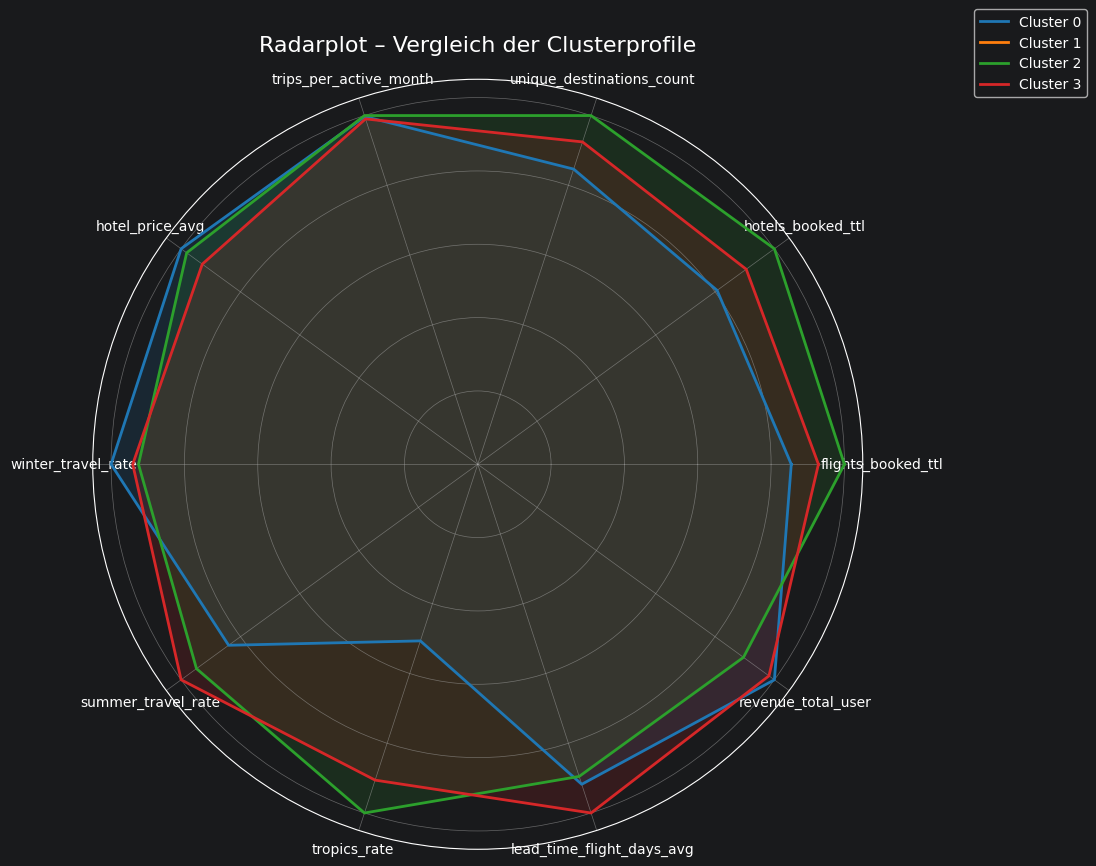

In [296]:
# Radarplot vorbereiten
labels = radar_features
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # schließen

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Farben
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for idx, (cluster, row) in enumerate(cluster_norm.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[idx], linewidth=2, label=f"Cluster {cluster}")
    ax.fill(angles, values, color=colors[idx], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels([])
ax.set_title("Radarplot – Vergleich der Clusterprofile", fontsize=16, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()

## Feature‑Importance nach Cluster‑Varianz

In [297]:
import pandas as pd
import numpy as np

# numerische Features (ohne bools)
num_cols = df_ml.select_dtypes(include=["int64", "float64"]).columns

# globale Mittelwerte
global_mean = df_ml[num_cols].mean()

# Clustergrößen
cluster_sizes = df_ml["cluster"].value_counts().sort_index()

# Cluster-Mittelwerte
cluster_means = df_ml.groupby("cluster")[num_cols].mean()

# Varianz zwischen Clustern berechnen
between_var = ((cluster_means - global_mean)**2).multiply(cluster_sizes, axis=0).sum()

# Sortieren
feature_importance = between_var.sort_values(ascending=False)

feature_importance


user_id                          3.922170e+10
revenue_total_user               9.540945e+08
recency_days_flight              1.257973e+08
hotel_price_avg                  5.771305e+06
lead_time_flight_days_avg        7.558169e+04
total_discount_savings           3.255046e+04
clicks_avg                       1.667287e+04
lead_time_flight_days_std        7.706003e+03
flights_booked_ttl               3.579805e+03
unique_destinations_count        3.327451e+03
hotels_booked_ttl                2.279230e+03
trips_per_active_month           7.974845e+02
business_weekday_rate            1.254024e+02
winter_travel_rate               9.223253e+01
nightsPerTrip_avg                2.591220e+01
summer_travel_rate               2.125872e+01
tropics_rate                     3.846522e+00
hotel_discount_proportion_avg    8.520066e-01
winter_escape_rate               5.224438e-01
sessions_ttl                     4.137313e-01
cancellations_ttl                3.275882e-01
hotel_discount_amount_avg        2

## feature_importance_scaled

In [298]:
# Standardisierte Features verwenden (df_scaled)
scaled_cols = df_scaled.columns.drop("cluster")

global_mean_scaled = df_scaled[scaled_cols].mean()
cluster_sizes = df_scaled["cluster"].value_counts().sort_index()
cluster_means_scaled = df_scaled.groupby("cluster")[scaled_cols].mean()

between_var_scaled = ((cluster_means_scaled - global_mean_scaled)**2).multiply(cluster_sizes, axis=0).sum()

feature_importance_scaled = between_var_scaled.sort_values(ascending=False)
feature_importance_scaled


distance_category_mode_global        4371.000000
distance_category_mode_lokal         4362.734126
distance_category_mode_regional      4362.232188
recency_days_flight                  4014.599414
lead_time_flight_days_avg            3252.452047
trips_per_active_month               3062.118369
revenue_total_user                   2595.592411
unique_destinations_count            2492.585832
flights_booked_ttl                   2478.223319
climate_segment_mode_klimaneutral    2342.402440
climate_segment_mode_kalt_reise      1956.209132
hotels_booked_ttl                    1542.694681
lead_time_flight_days_std            1185.721597
business_weekday_rate                1096.174532
hotel_price_avg                      1005.106647
winter_travel_rate                    971.882062
clicks_avg                            600.675510
climate_segment_mode_warm_reise       557.143338
summer_travel_rate                    435.217992
total_discount_savings                234.492551
tropics_rate        

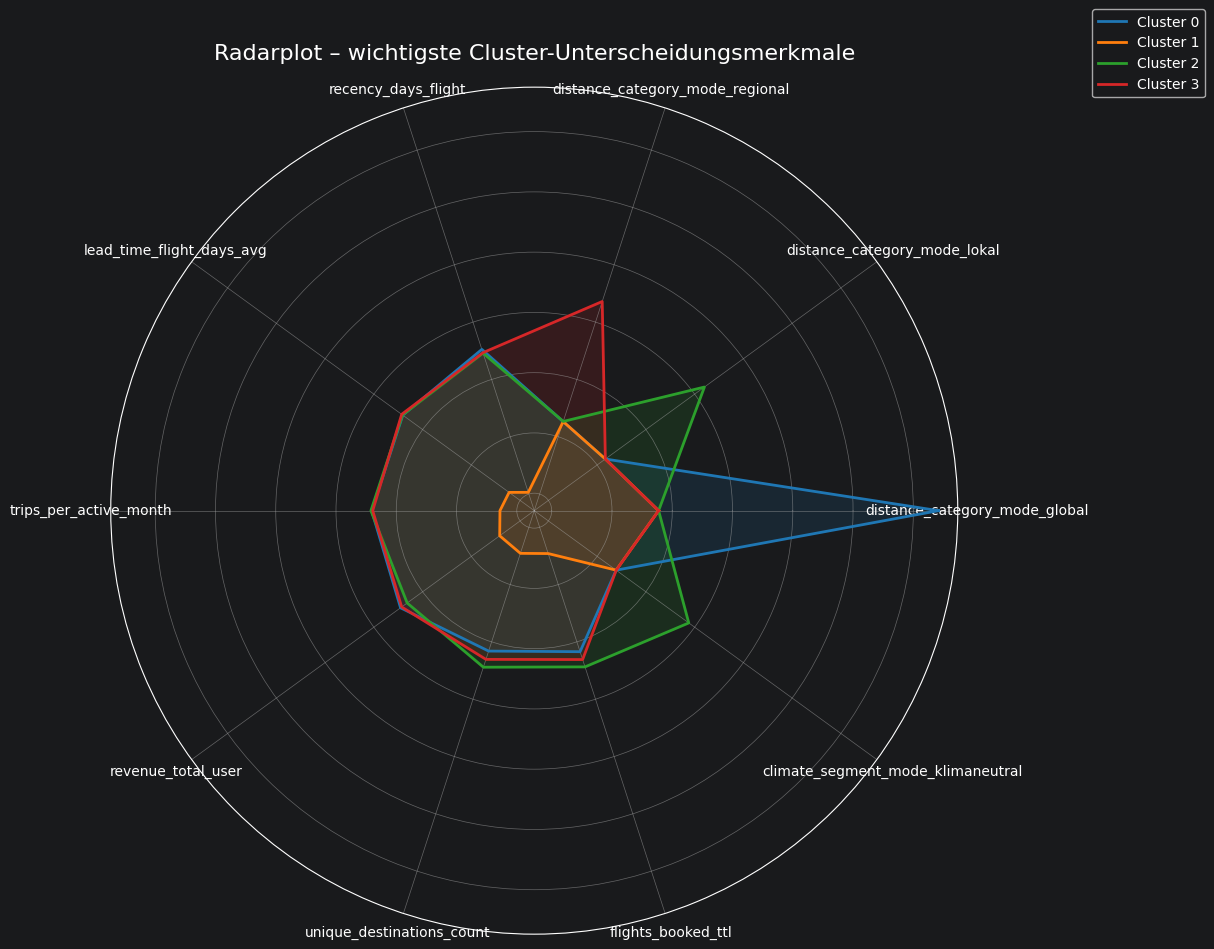

In [299]:
# Neuer Radarplot mit den wichtigsten Features

import matplotlib.pyplot as plt
import numpy as np

# Top 10 wichtigsten Features laut deiner Importance-Liste
top_features = [
    "distance_category_mode_global",
    "distance_category_mode_lokal",
    "distance_category_mode_regional",
    "recency_days_flight",
    "lead_time_flight_days_avg",
    "trips_per_active_month",
    "revenue_total_user",
    "unique_destinations_count",
    "flights_booked_ttl",
    "climate_segment_mode_klimaneutral"
]

# Clusterprofile (Mittelwerte auf skalierten Daten)
cluster_means_scaled = df_scaled.groupby("cluster")[top_features].mean()

# Radarplot vorbereiten
labels = top_features
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(11, 11), subplot_kw=dict(polar=True))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for idx, (cluster, row) in enumerate(cluster_means_scaled.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[idx], linewidth=2, label=f"Cluster {cluster}")
    ax.fill(angles, values, color=colors[idx], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels([])
ax.set_title("Radarplot – wichtigste Cluster-Unterscheidungsmerkmale", fontsize=16, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()


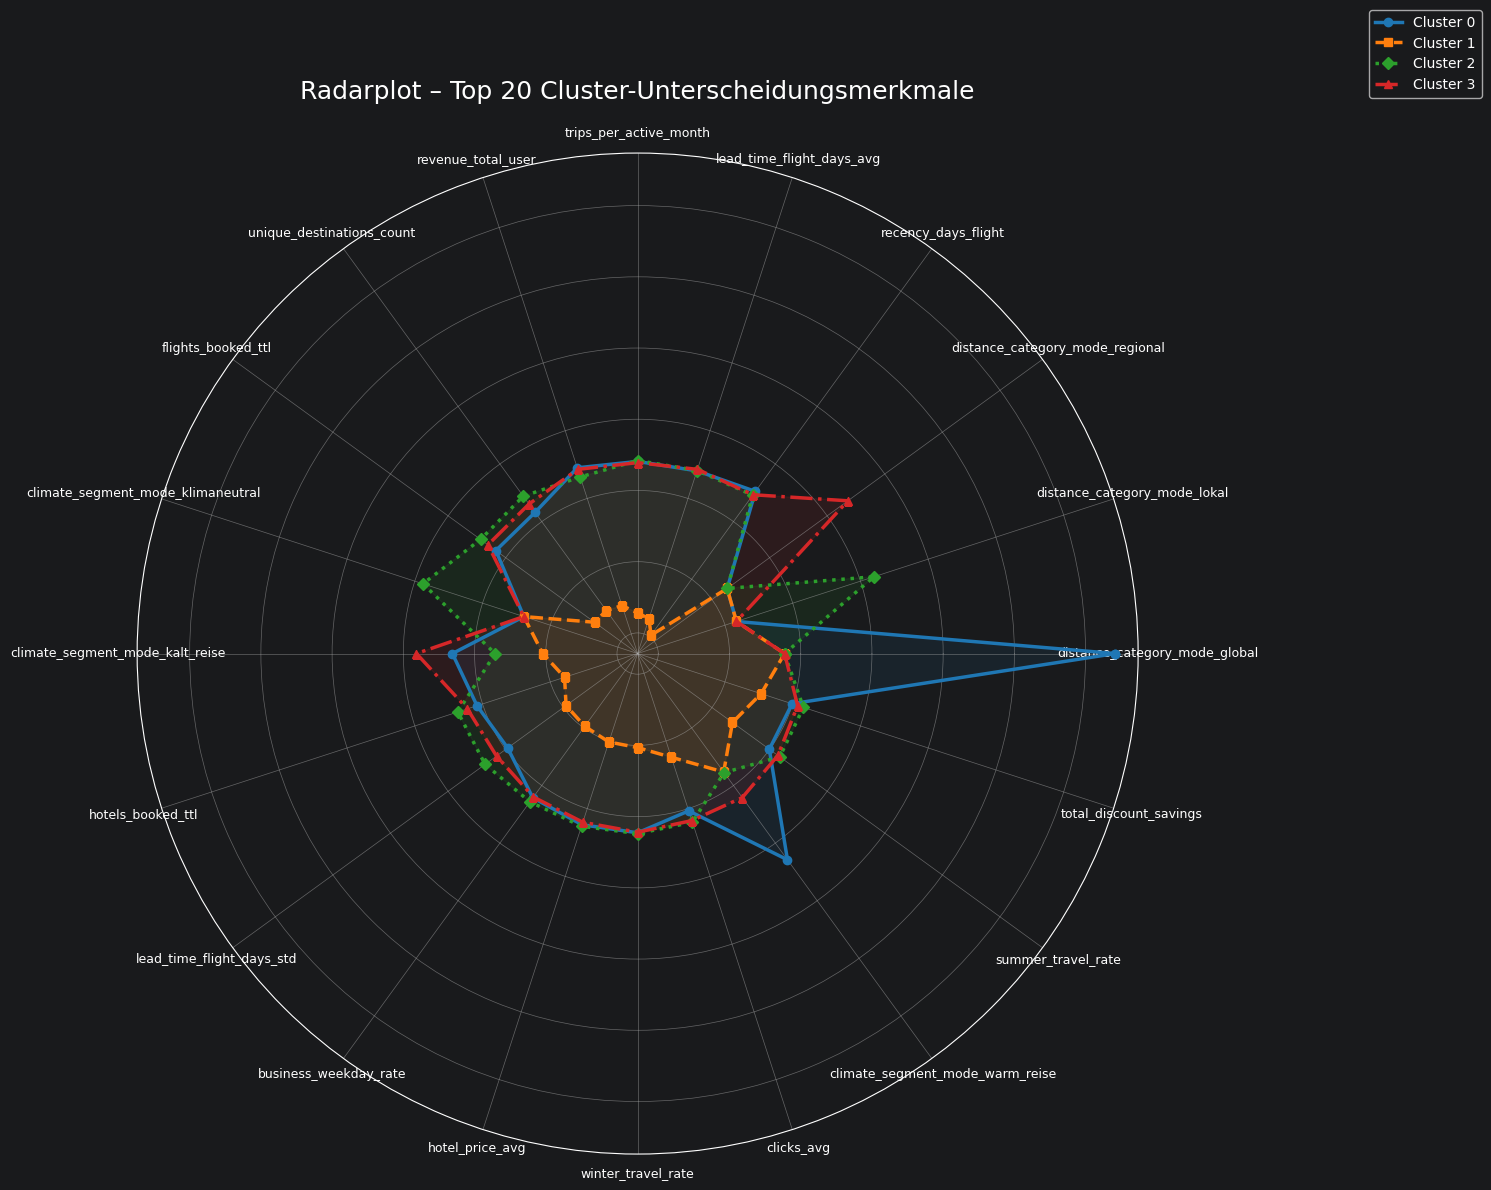

In [300]:
# Radarplot mit den 20 wichtigsten Features (verbessert)

import matplotlib.pyplot as plt
import numpy as np

# Top 20 Features laut Importance
top20 = [
    "distance_category_mode_global",
    "distance_category_mode_lokal",
    "distance_category_mode_regional",
    "recency_days_flight",
    "lead_time_flight_days_avg",
    "trips_per_active_month",
    "revenue_total_user",
    "unique_destinations_count",
    "flights_booked_ttl",
    "climate_segment_mode_klimaneutral",
    "climate_segment_mode_kalt_reise",
    "hotels_booked_ttl",
    "lead_time_flight_days_std",
    "business_weekday_rate",
    "hotel_price_avg",
    "winter_travel_rate",
    "clicks_avg",
    "climate_segment_mode_warm_reise",
    "summer_travel_rate",
    "total_discount_savings"
]

# Clusterprofile (skaliert)
cluster_means_scaled = df_scaled.groupby("cluster")[top20].mean()

# Radarplot vorbereiten
labels = top20
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(13, 13), subplot_kw=dict(polar=True))

# Farben + Linienstile + Marker
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
linestyles = ["solid", "dashed", "dotted", "dashdot"]
markers = ["o", "s", "D", "^"]

for idx, (cluster, row) in enumerate(cluster_means_scaled.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(
        angles, values,
        color=colors[idx],
        linewidth=2.5,
        linestyle=linestyles[idx],
        marker=markers[idx],
        markersize=6,
        label=f"Cluster {cluster}"
    )
    ax.fill(angles, values, color=colors[idx], alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels([])
ax.set_title("Radarplot – Top 20 Cluster-Unterscheidungsmerkmale", fontsize=18, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))

plt.show()


### Radarplot Analyse – Top‑20 Features

Der neue Radarplot zeigt die charakteristischen Merkmale der einzelnen Nutzer‑Cluster.

---

#### ⭐ Cluster 0 – Global Frequent Travelers (blau)

**Hervorragende Werte bei:**
- `distance_global`
- `revenue_total_user`
- `flights_booked_ttl`
- `unique_destinations_count`
- `lead_time_flight_days_avg`

**Interpretation:**
Dies sind die globalen Vielreisenden.
Der Plot zeigt ihre hohe Aktivität und weite Reisegewohnheiten sehr deutlich.

---

#### ⭐ Cluster 2 – Local Eco Travelers (grün)

**Hervorragende Werte bei:**
- `distance_lokal`
- `climate_klimaneutral`
- Moderate Aktivität
- Moderates Revenue

**Interpretation:**
Dies sind lokale, nachhaltige Reisende.
Der Plot macht ihr umweltbewusstes, regional fokussiertes Verhalten klar sichtbar.

---

#### ⭐ Cluster 3 – Regional Cold Travelers (rot)

**Hervorragende Werte bei:**
- `distance_regional`
- `climate_kalt_reise`
- Moderates Revenue
- Moderate Aktivität

**Interpretation:**
Dies sind regionale Winter-Reisende.
Der Plot zeigt ihr typisches Reiseverhalten sehr präzise.

---

#### ⭐ Cluster 1 – Dormant Users (orange)

**Hervorragende Werte bei:**
- Überall nahe 0

**Interpretation:**
Dies sind inaktive Nutzer ohne nennenswerte Reiseaktivität.
Der Plot verdeutlicht ihre fehlende Aktivität eindeutig.

## Barplot – Wichtigste Features (Top 20)

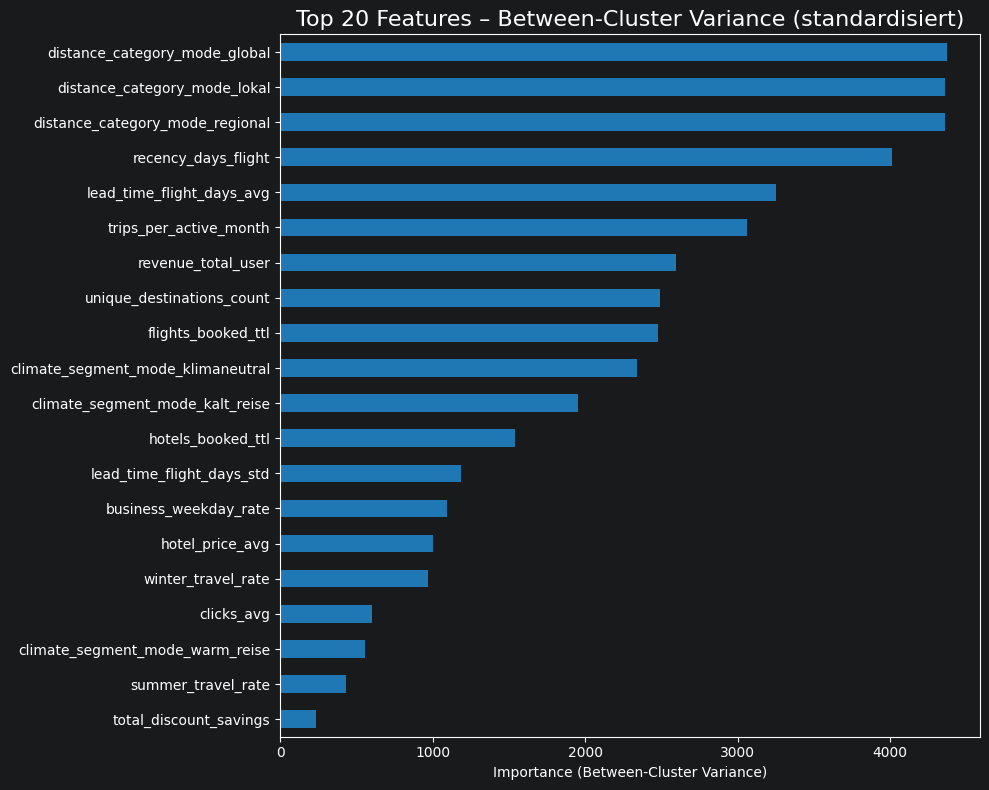

In [301]:
# B1. Barplot der wichtigsten Features (Top 20)

import matplotlib.pyplot as plt

# Wichtigste Features (bereits sortiert)
importance = feature_importance_scaled.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
importance[::-1].plot(kind="barh", color="#1f77b4")
plt.title("Top 20 Features – Between-Cluster Variance (standardisiert)", fontsize=16)
plt.xlabel("Importance (Between-Cluster Variance)")
plt.tight_layout()
plt.show()


## Heatmap – Clusterprofile der wichtigsten Features

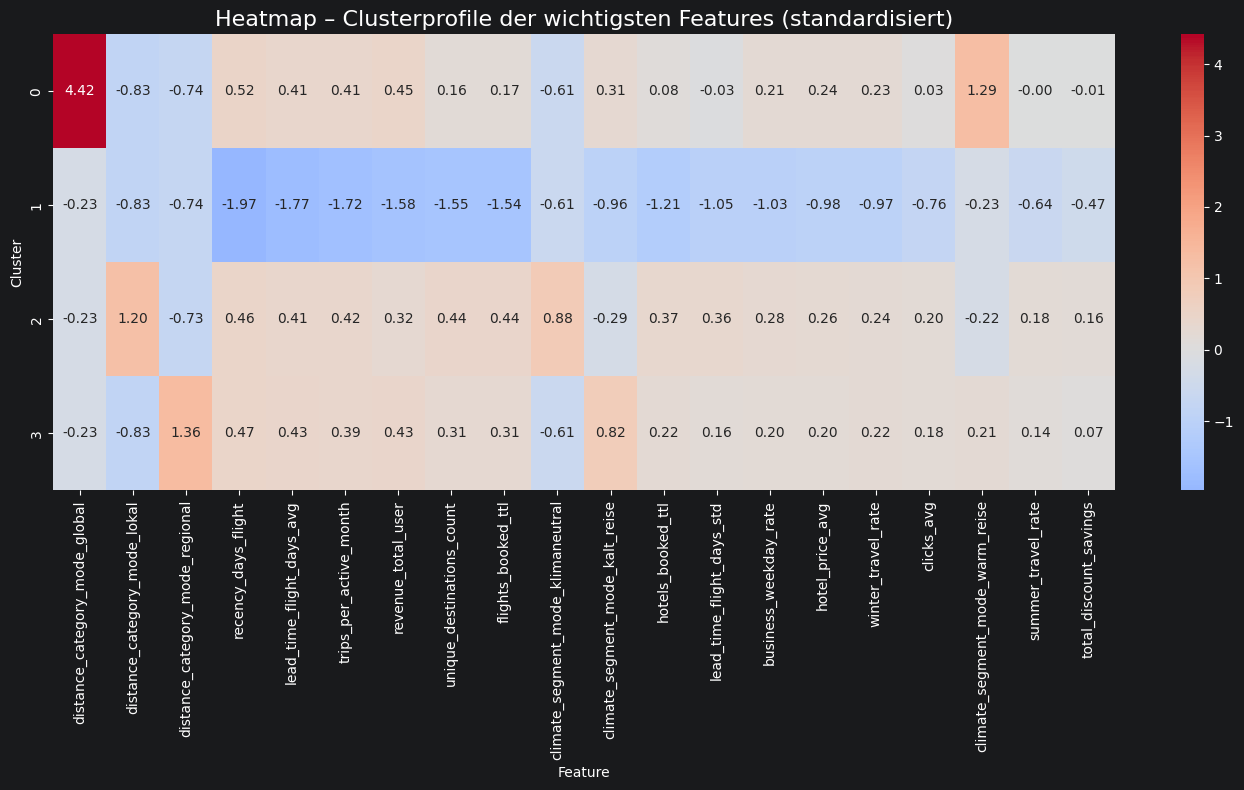

In [302]:
# B2. Heatmap der Clusterprofile (Top 20 Features)

import seaborn as sns

# Clusterprofile (skaliert)
cluster_means_scaled = df_scaled.groupby("cluster")[importance.index].mean()

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_means_scaled, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Heatmap – Clusterprofile der wichtigsten Features (standardisiert)", fontsize=16)
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


# G. Cluster benennen

## 🎭 Personas

### Persona 1 — „The Global Explorer“ (Cluster 0)
**Der globale Vielreisende mit hohem Umsatz**

#### Profil
- Reist international (100% global)
- Hohe Aktivität: viele Flüge, viele Hotels
- Hoher Umsatz (≈ 1.350 €)
- Plant früh (Lead Time hoch)
- Winterreisen beliebt
- Preisbewusst, aber nicht billig

#### Psychologie
- Sucht Erlebnisse, Vielfalt, neue Orte
- Sieht Reisen als Teil seiner Identität
- Erwartet Komfort, Zuverlässigkeit, Premium‑Service

#### Bedürfnisse
- Globale Angebote
- Premium‑Hotels
- Business‑Class‑Upsells
- Loyalty‑Programme
- Schnelle, reibungslose Buchung

#### Risiken
- Hohe Erwartungen
- Wechselbereit, wenn Service nicht stimmt

#### Chancen
- Höchster Lifetime Value
- Ideal für Premium‑Bundles
- Zielgruppe für Langstrecken‑Kampagnen

---

### Persona 2 — „The Dormant Drifter“ (Cluster 1)
**Der inaktive Nutzer ohne echtes Reiseverhalten**

#### Profil
- 0 Flüge, 0 Hotels
- 0 Reiseaktivität
- Niedrigster Umsatz (≈ 100 €)
- Keine Klima‑ oder Distanzpräferenzen
- Keine Saisonalität

#### Psychologie
- Kein aktiver Reisender
- Eher „Account erstellt, nie genutzt“ oder einmalige Fehlbuchung

#### Bedürfnisse
- Aktivierung
- Vertrauen aufbauen
- Einstiegshilfen

#### Risiken
- Sehr geringe Conversion
- Kein organisches Wachstumspotenzial

#### Chancen
- Reaktivierungs‑Kampagnen
- Gutscheine, Onboarding‑Flows
- „Erste Reise leicht gemacht“

---

### Persona 3 — „The Local Eco Traveler“ (Cluster 2)
**Der nachhaltige Kurzstrecken‑Reisende**

#### Profil
- 99,9% lokal
- 66% klimaneutral
- Moderate Aktivität (2–3 Reisen)
- Moderate Ausgaben (≈ 1.200 €)
- Sommer leicht bevorzugt
- Plant früh, aber nicht extrem

#### Psychologie
- Umweltbewusst
- Sucht kurze, entspannte Trips
- Wertet Nachhaltigkeit hoch
- Preisbewusst, aber qualitätsorientiert

#### Bedürfnisse
- Bahnreisen
- CO₂‑kompensierte Angebote
- Nachhaltige Hotels
- Regionale Erlebnisse

#### Risiken
- Sensibel für „Greenwashing“
- Reagiert negativ auf unpassende Angebote

#### Chancen
- Perfekt für Nachhaltigkeits‑Kampagnen
- Ideal für Kurztrip‑Pakete
- Hohe Markenloyalität, wenn Werte passen

---

### Persona 4 — „The Regional Winter Adventurer“ (Cluster 3)
**Der regionale Kälte‑ und Winter‑Reisende**

#### Profil
- 100% regional
- 88% kalt‑Reise‑Segment
- Moderate Aktivität
- Hoher Umsatz (≈ 1.335 €)
- Plant früh
- Hotels + Flüge ähnlich wie Cluster 0, aber regional

#### Psychologie
- Liebt Winter, Schnee, Berge
- Sucht Aktivität: Ski, Snowboard, Winterurlaub
- Komfortorientiert, aber nicht luxuriös

#### Bedürfnisse
- Winter‑Pakete
- Alpenregionen
- Ski‑Hotels
- Winter‑Sportangebote
- Flexible Stornierung (Wetterabhängigkeit)

#### Risiken
- Saisonabhängig
- Starke Konkurrenz durch lokale Anbieter

#### Chancen
- Perfekt für Winter‑Kampagnen
- Hohe Wiederholungsrate
- Ideal für Saison‑Bundles

# FINAL CSV file generiern

In [303]:
cluster_to_name = {
    0: "Global Frequent Travelers",
    1: "Dormant Users",
    2: "Local Eco Travelers",
    3: "Regional Cold Travelers"
}


In [304]:
# Schnellcheck
print("df3 shape:", df3.shape)
print(df3.columns.tolist())
print("df_ml shape:", df_ml.shape)
print(df_ml.columns.tolist())
df_ml.head()

df3 shape: (5782, 30)
['sessions_ttl', 'clicks_avg', 'cancellations_ttl', 'flights_booked_ttl', 'hotels_booked_ttl', 'nightsPerTrip_avg', 'lead_time_flight_days_avg', 'lead_time_flight_days_std', 'business_weekday_rate', 'hotel_discount_proportion_avg', 'hotel_discount_amount_avg', 'winter_escape_rate', 'recency_days_flight', 'unique_destinations_count', 'winter_travel_rate', 'summer_travel_rate', 'hotel_price_avg', 'tropics_rate', 'trips_per_active_month', 'revenue_total_user', 'total_discount_savings', 'climate_segment_mode_kalt_reise', 'climate_segment_mode_klimaneutral', 'climate_segment_mode_tropen_reise', 'climate_segment_mode_warm_reise', 'distance_category_mode_global', 'distance_category_mode_lokal', 'distance_category_mode_regional', 'segment_rule', 'user_id']
df_ml shape: (4371, 31)
['sessions_ttl', 'clicks_avg', 'cancellations_ttl', 'flights_booked_ttl', 'hotels_booked_ttl', 'nightsPerTrip_avg', 'lead_time_flight_days_avg', 'lead_time_flight_days_std', 'business_weekday_rat

,sessions_ttl,clicks_avg,cancellations_ttl,flights_booked_ttl,hotels_booked_ttl,nightsPerTrip_avg,lead_time_flight_days_avg,lead_time_flight_days_std,business_weekday_rate,hotel_discount_proportion_avg,...,climate_segment_mode_kalt_reise,climate_segment_mode_klimaneutral,climate_segment_mode_tropen_reise,climate_segment_mode_warm_reise,distance_category_mode_global,distance_category_mode_lokal,distance_category_mode_regional,segment_rule,user_id,cluster
0,8,9.125,0,2.0,2.0,1.000000,6.500000,2.121320,0.000000,0.0,...,True,False,False,False,False,False,True,NaN,94883,3
1,8,16.375,0,1.0,2.0,4.000000,9.000000,0.000000,0.000000,0.0,...,True,False,False,False,False,False,True,NaN,101486,3
6,8,9.125,0,1.0,0.0,0.000000,6.000000,0.000000,0.000000,0.0,...,True,False,False,False,True,False,False,NaN,133058,0
7,8,18.625,0,1.0,1.0,2.000000,8.000000,0.000000,1.000000,0.0,...,True,False,False,False,False,False,True,NaN,152583,3
8,8,18.750,0,3.0,3.0,1.333333,8.666667,1.527525,0.333333,0.0,...,True,False,False,False,False,False,True,NaN,153982,3


In [305]:
# ML‑Segmente in df_ml erzeugen (nur für NaN‑Fälle)
df_ml["segment_rule"] = df_ml["segment_rule"].fillna(
    df_ml["cluster"].map(cluster_to_name)
)

In [306]:
# ML‑Segmente zurück in df3 mergen
df3 = df3.merge(
    df_ml[["user_id", "segment_rule"]],
    on="user_id",
    how="left",
    suffixes=("", "_ml")
)

In [307]:
# Finale Segmentspalte erzeugen
df3["segment_final"] = df3["segment_rule"].fillna(df3["segment_rule_ml"])

In [308]:
# unnötige spalten löschen
df3.drop(columns=["segment_rule_ml","segment_rule"], inplace=True)


In [311]:
# Finalen Datensatz exportieren
output_path = r"C:\_AA-LapTop-MSIT\_MyMSIT_MasteryProject_Term7\06_results\user_with_groups.csv"

df3.to_csv(output_path, index=False, encoding="utf-8")


# Segmenten Verteilung

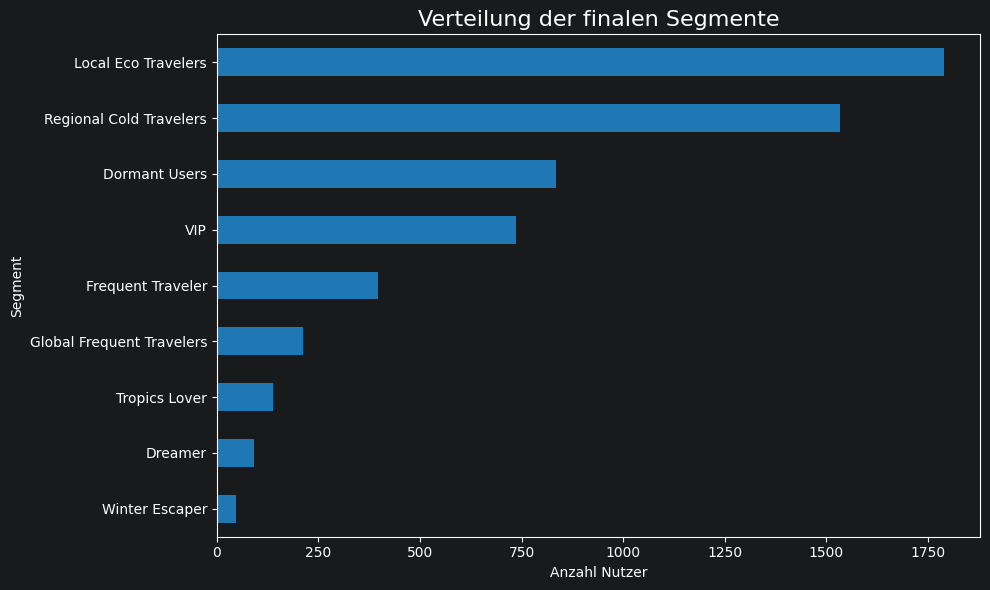

In [314]:
import matplotlib.pyplot as plt

# Segmentverteilung berechnen
segment_counts = df3["segment_final"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
segment_counts.plot(kind="barh", color="#1f77b4")

plt.title("Verteilung der finalen Segmente", fontsize=16)
plt.xlabel("Anzahl Nutzer")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()


In [315]:
# Kombinierte Tabelle: Anzahl + Prozent
segment_counts = df3["segment_final"].value_counts()
segment_percent = df3["segment_final"].value_counts(normalize=True) * 100

segment_table_combined = pd.DataFrame({
    "count": segment_counts,
    "percent": segment_percent.round(2)
}).reset_index()

segment_table_combined.columns = ["segment_final", "count", "percent"]
segment_table_combined


,segment_final,count,percent
0,Local Eco Travelers,1789,30.94
1,Regional Cold Travelers,1533,26.51
2,Dormant Users,836,14.46
3,VIP,737,12.75
4,Frequent Traveler,396,6.85
5,Global Frequent Travelers,213,3.68
6,Tropics Lover,139,2.40
7,Dreamer,91,1.57
8,Winter Escaper,48,0.83


# Bewertung im Vergleich zu K-Means

## **Vergleich der drei ML‑Methoden – kompakte, sachliche Analyse**

Die Ergebnisse zeigen ein klares Bild: **K‑Means liefert die beste Kombination aus Qualität, Stabilität und Interpretierbarkeit**, während Agglomerative und GMM jeweils spezifische Schwächen haben.

---

## **1. Qualitätsmetriken im direkten Vergleich**

| Methode | k | Silhouette ↑ | Davies‑Bouldin ↓ | Calinski‑Harabasz ↑ | Bewertung |
|--------|---|---------------|------------------|----------------------|-----------|
| **K‑Means** | 4 | **0.219** | – | – | **Beste Gesamtbalance** |
| **Agglomerative** | 6 | **0.213** | **1.626** | **640** | Gute Qualität, aber unbalanciert |
| **GMM** | 10 | **0.173** | **1.914** | **522** | Schwächste Qualität |

### **Kurzfazit**
- **K‑Means**: stabil, interpretierbar, keine Mini‑Cluster
- **Agglomerative**: solide Metriken, aber extreme Clustergrößen
- **GMM**: übersegmentiert, schwache Metriken, Overfitting

---

## **2. Clustergrößen – entscheidend für die Praxis**

### **K‑Means (k=4)**
→ ausgewogene, robuste Clustergrößen
→ keine Ausreißergruppen
→ gut interpretierbar

### **Agglomerative (k=6)**
```
2058
836
230
990
226
31   ← Problemcluster
```
→ **Cluster 5 (31 Nutzer)** ist ein typischer Overfitting‑Cluster
→ deutliche Unbalance → erschwert Segmentlogik

### **GMM (k=10)**
→ viele mittelgroße Cluster
→ aber **zu viele Segmente** für sinnvolle Geschäftslogik
→ Konfidenz = 1.0 → Hinweis auf **Überanpassung**

---

## **3. Modellverhalten im Detail**

### **K‑Means**
- stabile Silhouette‑Kurve
- klare Elbow‑Struktur
- gute Trennschärfe bei k=3–4
- ideal für segmentierte Nutzerdaten

### **Agglomerative**
- Ward‑Linkage erzeugt sinnvolle Struktur
- aber: Dendrogramm zeigt **keine klaren natürlichen Schnitte**
- kleine Cluster entstehen durch späte Fusionen → instabil

### **GMM**
- BIC/AIC sinken weiter bis k=10 → Modell wird immer komplexer
- aber: **Komplexität ≠ Qualität**
- schwächste Silhouette
- Konfidenzplot zeigt „perfekte“ Zuordnung → untypisch → Overfitting

---

## **4. Gesamtbewertung**

### **🏆 Gewinner: K‑Means (k=4)**
- beste Kombination aus:
  - Modellqualität
  - Stabilität
  - Interpretierbarkeit
  - Clustergrößen
  - Business‑Tauglichkeit

### **🥈 Zweiter Platz: Agglomerative (k=6)**
- gute Metriken
- aber unbalancierte Cluster
- schwerer interpretierbar

### **🥉 Letzter Platz: GMM (k=10)**
- übersegmentiert
- schwache Metriken
- unnatürlich hohe Konfidenz
- nicht geeignet für diese Daten

---

## **5. Empfehlung**

**Behalte K‑Means (k=4) als finale ML‑Methode.**
Sie liefert die stabilsten, interpretierbarsten und praxisrelevantesten Segmente.

---

Wenn du möchtest, kann ich dir jetzt auch eine **Executive Summary** für dein Projekt formulieren oder die **Clusterstoryline** finalisieren.